In [1]:
from stable_baselines3 import PPO
from src.optimizer.reinforce.lgwr_optimizer import LgwrOptimizerRL
from src.dataset.simulated_spatial_dataset import SimulatedSpatialDataset
from src.kernel.lgwr_kernel import LgwrKernel
from src.kernel.gwr_kernel import GwrKernel
from src.model.gwr import GWR
from src.model.lgwr import LGWR
import numpy as np

In [2]:
# Create a simulated dataset.
field_size = 40
dataset = SimulatedSpatialDataset(field_size=field_size)
[X] = dataset.generate_data()
[beta] = dataset.generate_processes()
[y, err] = dataset.fit_y(X, beta)

In [3]:
global_bandwidth = 70

kernel = GwrKernel(
    dataset,
    kernel_type='bisquare'
)
gwr = GWR(dataset, kernel)

# Create a LGWR kernel and LGWR model.
kernel = LgwrKernel(
    dataset,
    kernel_type='bisquare',
    kernel_bandwidth_type='adaptive'
)
lgwr = LGWR(dataset, kernel)

In [4]:
gwr.update_bandwidth(global_bandwidth).fit()

llf: -2164.8364184926822
tr_S: 175.98106876159022
----------------------
first: 4329.6728369853645
second: 398.2643322082036
----------------------
up: 566339.4200370887
down: 1422.0189312384098
AICc: 4727.9371691935685 



In [5]:
lgwr.update_local_bandwidth_vector(
    np.full(dataset.n, global_bandwidth)
).fit()

llf: -2164.8364184926822
tr_S: 175.98106876159022
----------------------
first: 4329.6728369853645
second: 398.2643322082036
----------------------
up: 566339.4200370887
down: 1422.0189312384098
AICc: 4727.9371691935685 



Read PPO optimized bandwidth vectors

In [6]:

from pathlib import Path
import json
from pprint import pprint
path = Path("./model_info.json")
with path.open("r", encoding="utf-8") as f:
    mode_info = json.load(f)
bandwidth_vectors = mode_info['bandwidth_optimization']


Find the bandwidth vectors perform better than uniform bandwidth in terms of AICc

In [7]:
better_bandwidth_vectors = []
for vector in bandwidth_vectors:
    if vector["reward"] <= lgwr.aicc:
        better_bandwidth_vectors.append(vector)

In [8]:
import ast
import matplotlib.pyplot as plt
from matplotlib import colormaps

def load_bandwidth_vector(bandwidth_str):
    bandwidth = ast.literal_eval(bandwidth_str)
    bandwidth = np.array([int(x) for x in bandwidth])
    return bandwidth

def plot(b, sub_title=['', '', '', ''], size=40, vmin=None, vmax=None, palette='viridis'):
    k = len(b)
    fig, axs = plt.subplots(1, k, figsize=(6*k, 4))
    if k == 1:
        axs = [axs]
    for i in range(k):
        if i == 0:
            ax = axs[i].imshow(b[i].reshape(size, size),
                                cmap=colormaps[palette], vmin=vmin, vmax=vmax)
        else:  # plt.cm.get_cmap('viridis', 21)
            ax = axs[i].imshow(b[i].reshape(size, size),
                                cmap=colormaps[palette], vmin=vmin, vmax=vmax)
        axs[i].set_title(sub_title[i], fontsize=16)
        fig.colorbar(ax, ax=axs[i])

        axs[i].set_xticks(np.arange(-0.5, 40, 5))
        axs[i].set_yticks(np.arange(-0.5, 40, 5))
        axs[i].set_xticklabels([])
        axs[i].set_yticklabels([])

        axs[i].tick_params(axis='x', colors=(0, 0, 0, 0))
        axs[i].tick_params(axis='y', colors=(0, 0, 0, 0))
    plt.show()


Plot bandwidth maps, similar AICc values, but different spatial configurations

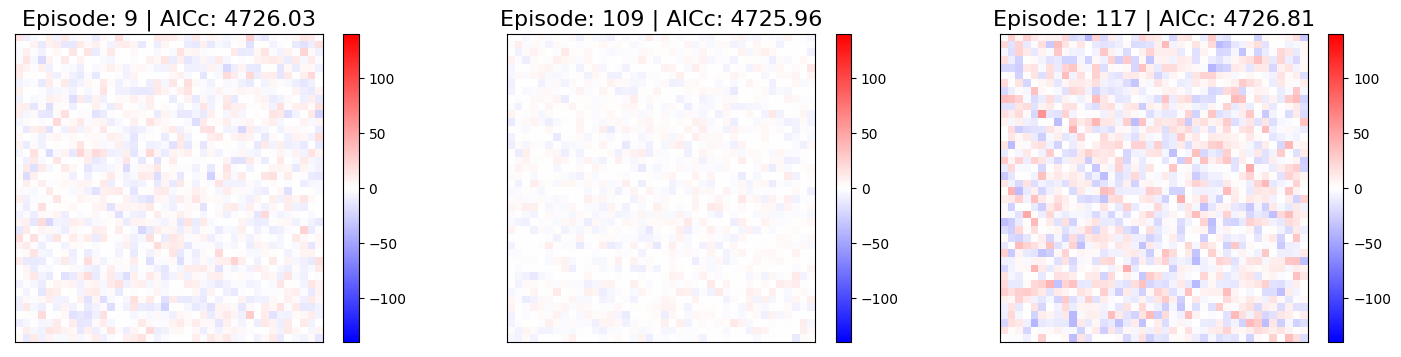

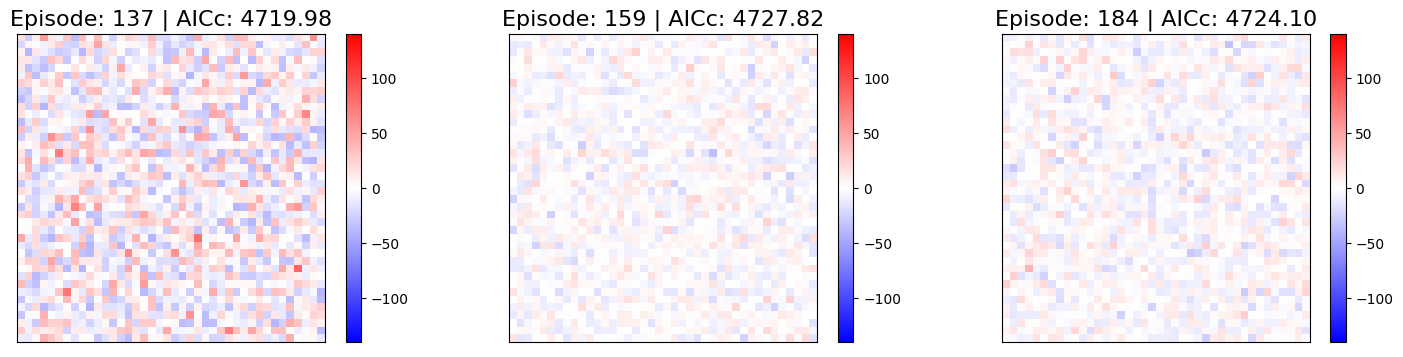

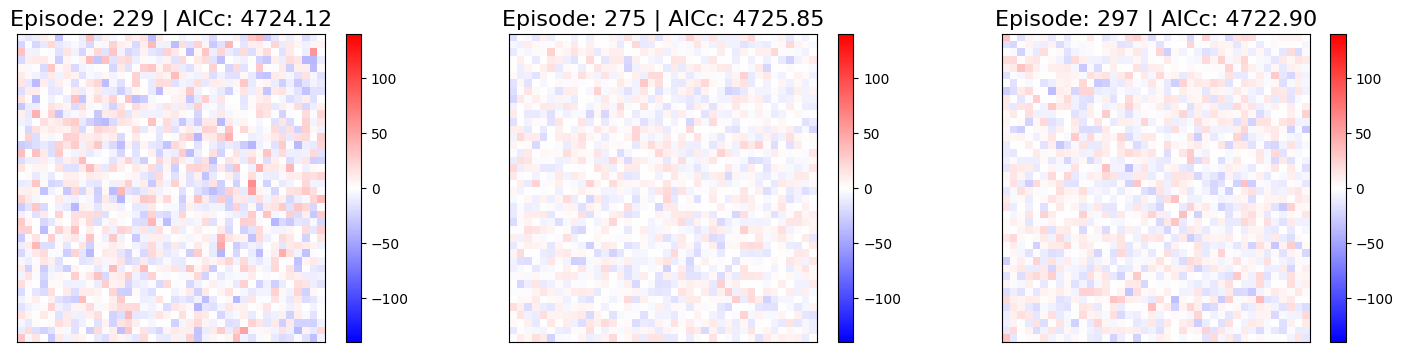

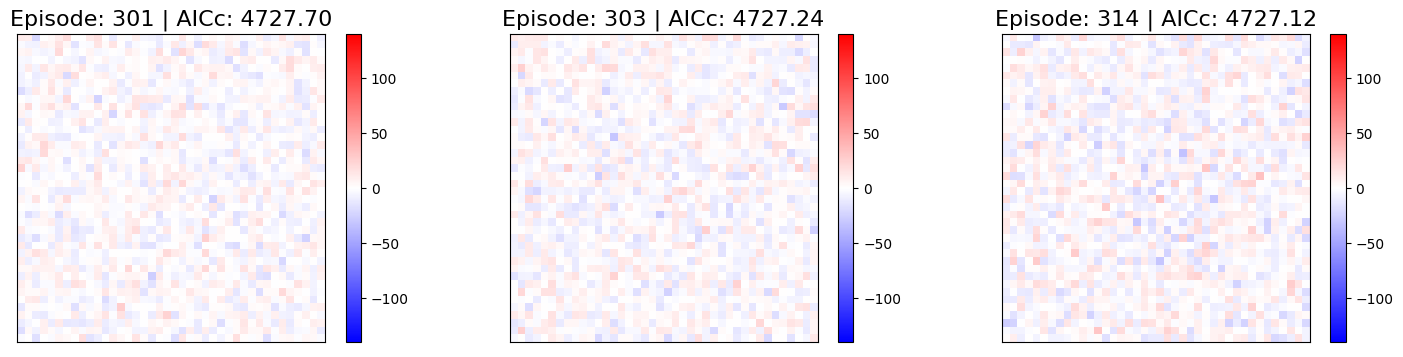

In [13]:
plot_vectors = []
plot_index = []
plot_caption = []

for i, vector in enumerate(better_bandwidth_vectors):

    bws = load_bandwidth_vector(vector['bandwidth'])
    

    plot_vectors.append(bws.reshape(1,-1))
    plot_index.append(i)
    plot_caption.append(
        f"Episode: {vector['episode']} | AICc: {vector['reward']:.2f}"
    )
    
plot_vectors = np.vstack(plot_vectors)
plot_vectors_action = np.vstack(plot_vectors) - global_bandwidth

bound = max(abs(plot_vectors_action.max()), abs(plot_vectors_action.min())) * 1.1
color = 'bwr'

plot(
    b=plot_vectors_action[:3],
    sub_title=plot_caption[:3],
    size=field_size,
    palette=color,
    vmax=bound,
    vmin=-bound
)

plot(
    b=plot_vectors_action[3:6],
    sub_title=plot_caption[3:6],
    size=field_size,
    palette=color,
    vmax=bound,
    vmin=-bound
)


plot(
    b=plot_vectors_action[6:9],
    sub_title=plot_caption[6:9],
    size=field_size,
    palette=color,
    vmax=bound,
    vmin=-bound
)


plot(
    b=plot_vectors_action[9:12],
    sub_title=plot_caption[9:12],
    size=field_size,
    palette=color,
    vmax=bound,
    vmin=-bound
)

In [10]:
lgwr.update_local_bandwidth_vector(
    np.full(dataset.n, global_bandwidth)
).fit()

lgwr.update_local_bandwidth_vector(
    plot_vectors[0]
).fit()
lgwr.update_local_bandwidth_vector(
    plot_vectors[3]
).fit()

llf: -2164.8364184926822
tr_S: 175.98106876159022
----------------------
first: 4329.6728369853645
second: 398.2643322082036
----------------------
up: 566339.4200370887
down: 1422.0189312384098
AICc: 4727.9371691935685 

llf: -2144.486570274352
tr_S: 191.1467857625235
----------------------
first: 4288.973140548704
second: 437.05321082365975
----------------------
up: 614869.7144400752
down: 1406.8532142374765
AICc: 4726.026351372363 

llf: -2122.410311496744
tr_S: 205.73479219808837
----------------------
first: 4244.820622993488
second: 475.16186666643097
----------------------
up: 661551.3350338828
down: 1392.2652078019116
AICc: 4719.982489659918 

